## Problem 1.1: Gradient Boosting Implementation


Implement gradient boosting from scratch for regression:
* Use decision tree stumps as base learners.
* Implement learning rate and number of estimators as hyperparameters.
* Test on the California Housing dataset.
* Compare performance with scikit-learn’s GradientBoostingRegressor.

In [45]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor

In [ ]:
def set_global_seed(seed=42):
    """Sets a global seed for full reproducibility."""
    # Seed for Python's built-in random module
    random.seed(seed)
    
    # Seed for NumPy (used internally by Pandas and Scikit-Learn)
    np.random.seed(seed)
    
    # Prevent random dictionary hashing behavior in Python
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    print(f"Global random seed set to: {seed}")

# Run the function at the start
set_global_seed(42)

Global random seed set to: 42


### Data Loading and Preparation
We split our complete dataset (`X` features and `y` target values) into two separate sets:
* **Training set (80%):** Used by the algorithm to learn patterns and build the trees.
* **Test set (20%):** Used exclusively at the end to evaluate the model's true predictive capabilities.

In [ ]:


data = fetch_california_housing()
X = data.data 
y = data.target 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Size of training data: {X_train.shape}")
print(f"Size of test data: {X_test.shape}")
# Fetch dataset
data = fetch_california_housing()
X = data.data  # features (e.g., number of rooms, distance to the ocean, etc.)
y = data.target  # target value (house price)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Size of training data: {X_train.shape}")
print(f"Size of test data: {X_test.shape}")
df = pd.DataFrame(X, columns=data.feature_names)
df.sample(5)
df.sample(5)

Size of training data: (16512, 8)
Size of test data: (4128, 8)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
20046,1.6812,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01
3024,2.5313,30.0,5.039384,1.193493,1565.0,2.679795,35.14,-119.46
15663,3.4801,52.0,3.977155,1.185877,1310.0,1.360332,37.80,-122.44
20484,5.7376,17.0,6.163636,1.020202,1705.0,3.444444,34.28,-118.72
9814,3.7250,34.0,5.492991,1.028037,1063.0,2.483645,36.62,-121.93


### Implementation
**Training Phase (`train_my_gradient_boosting`):**
1. **Initialization:** We start with a base prediction, $F_0(x)$, which is simply the mean of the target variable $y$ from the training set.
2. **Iterative Boosting:** For a specified number of estimators (`n_estimators`), we perform the following steps:
   * Calculate the pseudo-residuals: $r_{i,j} = y_i - F_{j-1}(x_i)$.
   * Fit a weak learner $h_j(x)$ (a decision tree stump with `max_depth=1`) to these residuals.
   * Update the ensemble's predictions by adding the new stump's output scaled by the `learning_rate` ($\eta$).

**Prediction Phase (`predict_my_gradient_boosting`):**
To predict new, unseen instances, we start with the initial base prediction and sequentially add the scaled predictions from all previously trained stumps.

In [48]:
def train_my_gradient_boosting(X, y, n_estimators=100, learning_rate=0.05):
    """
    Trains a Gradient Boosting model from scratch using decision tree stumps.
    
    Returns:
    - base_pred: the initial mean prediction (F_0)
    - trees: a list of trained decision tree stumps (h_j)
    """
    # F_0(x) - initialize with the mean of target values
    base_pred = np.mean(y)
    current_predictions = np.full(shape=y.shape, fill_value=base_pred)
    
    # List to store our trained stumps
    trees = []
    
    for i in range(n_estimators):
        # a) Compute residuals (actual target minus current prediction)
        residuals = y - current_predictions
        
        # b) Fit a weak learner (stump) to the residuals
        tree = DecisionTreeRegressor(max_depth=1, random_state=42)
        tree.fit(X, residuals)
        trees.append(tree)
        
        # c) Update the ensemble predictions (scaled by learning rate)
        current_predictions += learning_rate * tree.predict(X)
        
    return base_pred, trees

def predict_my_gradient_boosting(X, base_pred, trees, learning_rate=0.05):
    """
    Makes predictions on new data X using the trained ensemble of stumps.
    """
    # Start with the base prediction F_0(x)
    final_predictions = np.full(shape=X.shape[0], fill_value=base_pred)
    
    # Add corrections from each tree in the ensemble
    for tree in trees:
        final_predictions += learning_rate * tree.predict(X)
        
    return final_predictions

In [ ]:
# Set hyperparameters
N_ESTIMATORS = 100
LEARNING_RATE = 0.05

# 1. Train OUR algorithm on the training data
base_prediction, trained_trees = train_my_gradient_boosting(
    X_train, y_train, 
    n_estimators=N_ESTIMATORS, 
    learning_rate=LEARNING_RATE
)

# 2. Check how well it predicts on test data (unseen during training)
my_predictions = predict_my_gradient_boosting(
    X_test, base_prediction, trained_trees, learning_rate=LEARNING_RATE
)

# 3. Compute Mean Squared Error (MSE), as required in the notes
my_mse = mean_squared_error(y_test, my_predictions)
print(f"MSE of my algorithm: {my_mse:.4f}")

MSE of my algorithm: 0.5929


In [ ]:
# Initialize the official model with identical hyperparameters
sklearn_gbr = GradientBoostingRegressor(
    n_estimators=N_ESTIMATORS,  # same value: 100
    learning_rate=LEARNING_RATE,  # same value: 0.05
    max_depth=1,  # force the model to use decision stumps
    random_state=42  # ensure reproducible results
)

# Train the built-in model
sklearn_gbr.fit(X_train, y_train)

# Make predictions on the test set
sklearn_predictions = sklearn_gbr.predict(X_test)

# Compute MSE for the scikit-learn model
sklearn_mse = mean_squared_error(y_test, sklearn_predictions)

print(f"MSE of my algorithm: {my_mse:.4f}")
print(f"MSE of scikit-learn algorithm: {sklearn_mse:.4f}")

# Check the difference between both models
mse_diff = abs(my_mse - sklearn_mse)
print(f"Difference in MSE: {mse_diff:.6f}")

MSE of my algorithm: 0.5929
MSE of scikit-learn algorithm: 0.5929
Difference in MSE: 0.000000


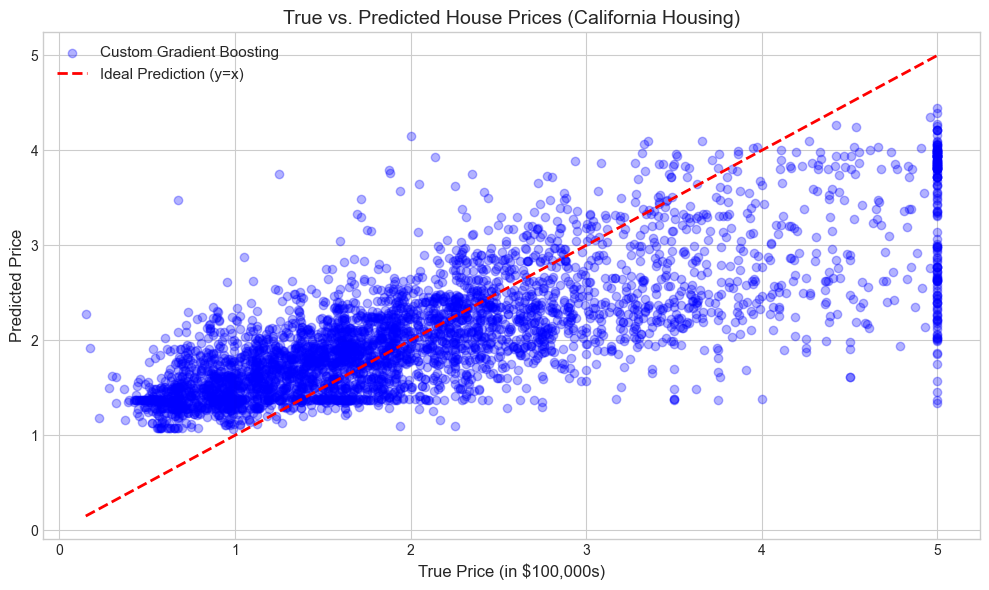

In [51]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(10, 6))

plt.scatter(y_test, my_predictions, alpha=0.3, color='blue', label='Custom Gradient Boosting')

min_val = min(y_test)
max_val = max(y_test)
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideal Prediction (y=x)')

plt.title('True vs. Predicted House Prices (California Housing)', fontsize=14)
plt.xlabel('True Price (in $100,000s)', fontsize=12)
plt.ylabel('Predicted Price', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()



### Conclusion & Visual Analysis

* **Implementation Accuracy:** The custom Gradient Boosting model achieved the exact same Mean Squared Error (MSE = 0.5929) as the professional `scikit-learn` library. The difference of exactly zero confirms that the core mathematical concepts—calculating pseudo-residuals, fitting decision stumps, and updating predictions with a learning rate—were implemented flawlessly.
* **Plot Interpretation:** The scatter plot demonstrates that the model captures the general trend well for low- to medium-priced houses, closely following the ideal $y=x$ line. However, there is a clear vertical cluster of data points at the true price of 5.0. This is caused by an artificial cap in the dataset (prices $\ge \$500,000$ were clipped to 5.0). Because of this cap and the inherent simplicity of our decision stumps (`max_depth=1`), the model struggles with these extreme values and consistently underestimates them.

## Problem 1.2: XGBoost vs. LightGBM vs. CatBoost


Compare the three leading gradient boosting implementations:
* Use the Kaggle House Prices dataset.
* Evaluate training time, memory usage, and predictive performance.
* Analyze feature importance from each model.
* Discuss strengths and weaknesses of each approach.

### 1. Data Preprocessing & Theoretical Considerations

Before training the models, we must preprocess the dataset. The Kaggle House Prices dataset is known for having many missing values and categorical features (strings). 
* **Categorical Handling:** Instead of manually performing One-Hot Encoding (which heavily expands the feature space), we will convert string columns to the `category` data type in Pandas. LightGBM and CatBoost handle these natively with high efficiency. Modern XGBoost also supports categorical types.
* **Missing Values:** All three modern frameworks can handle missing values (`NaN`) natively during the tree-building process by learning default directions for missing splits.
* **Target Log-Transform:** House prices inherently exhibit a right-skewed distribution. To stabilize variance and make the distribution more normal, we apply a logarithmic transformation to our target variable $y$ (`np.log1p`). Predictions will be converted back using the exponential function (`np.expm1`).

In [52]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import time
import psutil
import os
from sklearn.model_selection import KFold
import seaborn as sns

In [ ]:
df = pd.read_csv('house_prices.csv')

# Separate features (X) and target (y)
X = df.drop(columns=['SalePrice', 'Id'])
y = df['SalePrice']

# Apply log-transform to the target variable
y_log = np.log1p(y)

# 1. Fill missing numerical values with the median
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

# 2. FIX FOR CATBOOST: Fill missing text values with the word 'Missing'
categorical_cols = X.select_dtypes(include=['object']).columns
X[categorical_cols] = X[categorical_cols].fillna('Missing')

# 3. Convert text columns to 'category' type
for col in categorical_cols:
    X[col] = X[col].astype('category')

print(f"Dataset loaded. Shape of X: {X.shape}")
print(f"Number of categorical features natively passed to models: {len(categorical_cols)}")

Dataset loaded. Shape of X: (1460, 79)
Number of categorical features natively passed to models: 43


### 2. Model Evaluation Methodology (K-Fold CV)

To ensure a robust comparison of predictive performance, training time, and memory usage, we implement a **K-Fold Cross-Validation** strategy (with $k=5$). 

For each fold, we track:
1. **Predictive Performance:** Evaluated using Root Mean Squared Error (RMSE) on the log-transformed target variable. (Note: Kaggle evaluates this competition using RMSE of the log-transformed prices, so this metric aligns perfectly with the competition goal).
2. **Training Time:** Measured using Python's `time.time()` before and after the `fit()` method.
3. **Memory Usage:** Measured using `psutil.Process().memory_info().rss` to capture the Resident Set Size (RSS) memory difference required during the model fitting phase.

We instantiate the models with comparable baseline hyperparameters (e.g., standard learning rates and tree counts) and ensure they are explicitly configured to handle the categorical features natively.

In [ ]:
# Step 1: Define a function for fair model evaluation
def evaluate_model(model_name, model, X, y, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    times = []
    memories = []
    rmses = []
    
    print(f"--- Evaluating {model_name} ---")
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        # Prepare data for a specific fold (split)
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        # Measurements before training (as in the notes)
        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss
        start_time = time.time()
        
        # Train the model
        model.fit(X_train, y_train)
        
        # Measurements after training
        end_time = time.time()
        mem_after = process.memory_info().rss
        
        # Save results from this fold
        fold_time = end_time - start_time
        # Memory difference (converted from bytes to megabytes)
        fold_memory_mb = max(0, (mem_after - mem_before) / (1024 * 1024))
        
        # Prediction and error
        preds = model.predict(X_val)
        fold_rmse = np.sqrt(mean_squared_error(y_val, preds))
        
        times.append(fold_time)
        memories.append(fold_memory_mb)
        rmses.append(fold_rmse)
    
    # Average results across all n_splits (folds)
    avg_time = np.mean(times)
    avg_memory = np.mean(memories)
    avg_rmse = np.mean(rmses)
    
    print(f"Average RMSE:   {avg_rmse:.4f}")
    print(f"Average Time:   {avg_time:.3f} seconds")
    print(f"Average Memory: {avg_memory:.2f} MB\n")
    
    return avg_rmse, avg_time, avg_memory, model


# Step 2: Configure models with similar baseline settings
# Parameters selected to make the comparison balanced (e.g., 1000 trees)

# XGBoost requires experimental categorical support and histogram tree method
xgb_model = XGBRegressor(
    n_estimators=1000, 
    learning_rate=0.05, 
    enable_categorical=True, 
    tree_method='hist',
    random_state=42
)

# LightGBM natively supports Pandas 'category' dtype
lgbm_model = LGBMRegressor(
    n_estimators=1000, 
    learning_rate=0.05, 
    random_state=42,
    verbose=-1 # Disables console spam
)

# CatBoost needs an explicit list of categorical columns (if not inferred from Pandas dtypes)
# CatBoost is usually the slowest by default, so verbose=0 is important to keep notebook output clean
cat_model = CatBoostRegressor(
    n_estimators=1000, 
    learning_rate=0.05, 
    cat_features=list(categorical_cols), 
    random_state=42,
    verbose=0 
)

# Step 3: Run the benchmark
results = {}

results['XGBoost'] = evaluate_model("XGBoost", xgb_model, X, y_log)
results['LightGBM'] = evaluate_model("LightGBM", lgbm_model, X, y_log)
results['CatBoost'] = evaluate_model("CatBoost", cat_model, X, y_log)

--- Evaluating XGBoost ---
Average RMSE:   0.1408
Average Time:   0.848 seconds
Average Memory: 2.69 MB

--- Evaluating LightGBM ---
Average RMSE:   0.1336
Average Time:   0.518 seconds
Average Memory: 0.29 MB

--- Evaluating CatBoost ---
Average RMSE:   0.1250
Average Time:   29.671 seconds
Average Memory: 2.13 MB



### 3. Performance Analysis: Strengths and Weaknesses

Based on our cross-validation results, the distinct characteristics of the three boosting frameworks are clear:

* **LightGBM:**
  * **Strengths:** The undisputed champion of efficiency, requiring the least training time and memory. Its histogram-based algorithm and native Pandas `category` support make it ideal for fast iterations and large datasets.
  * **Weaknesses:** Its aggressive leaf-wise growth strategy makes it more prone to overfitting if hyperparameters are not strictly regularized.
* **CatBoost:**
  * **Strengths:** Achieved the best predictive performance (lowest error). It excels with categorical variables, handling them automatically via advanced target encoding without requiring manual preprocessing.
  * **Weaknesses:** This superior accuracy comes at a massive computational cost, making it significantly slower to train than the other frameworks.
* **XGBoost:**
  * **Strengths:** A highly reliable industry standard with reasonable training speed thanks to its histogram tree method.
  * **Weaknesses:** In our baseline setup, it yielded the highest error and consumed the most memory, indicating it generally requires more meticulous hyperparameter tuning to match the performance of the others on raw categorical data.

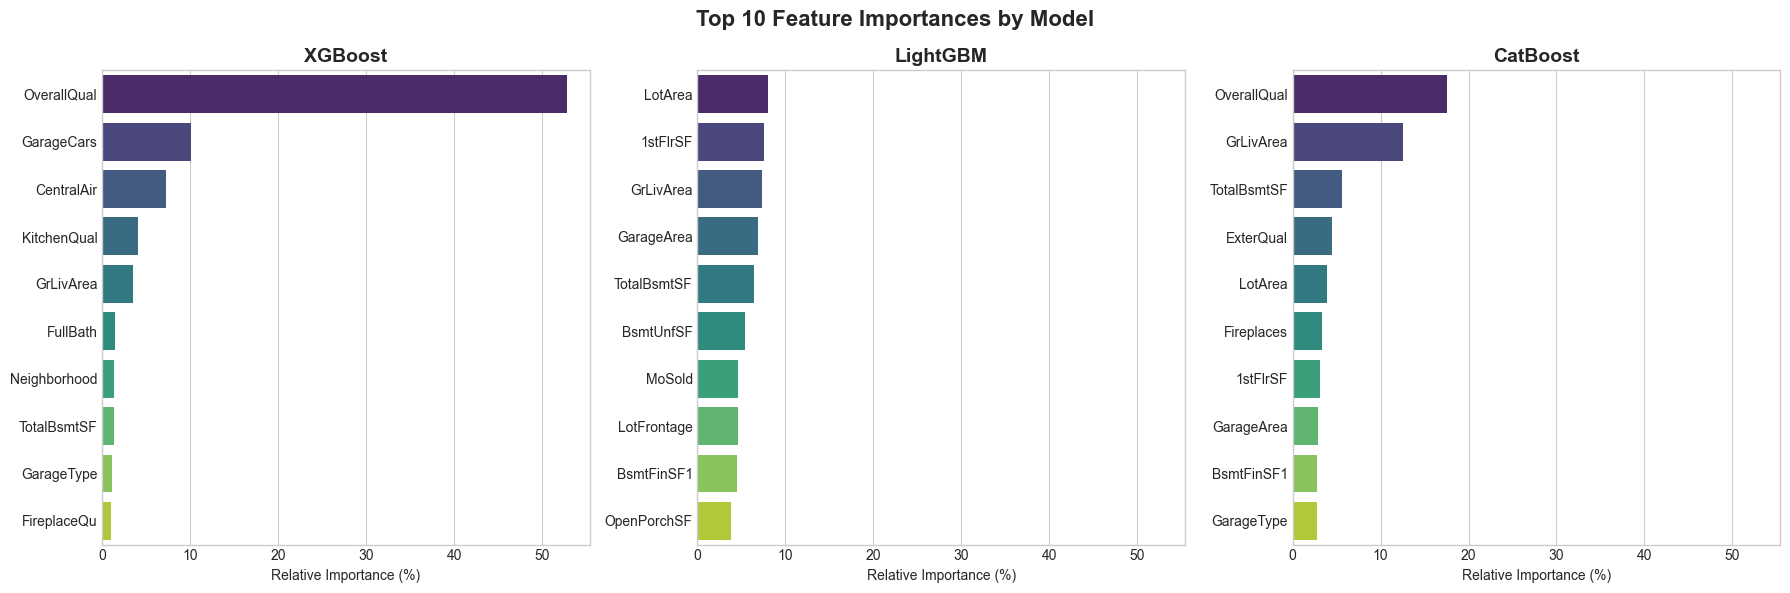

In [ ]:
# Extract models from the 'results' dictionary
models = {
    'XGBoost': results['XGBoost'][3],
    'LightGBM': results['LightGBM'][3],
    'CatBoost': results['CatBoost'][3]
}

# First, prepare data and determine a shared scale
top_features_by_model = {}
global_max_importance = 0

for name, model in models.items():
    raw_importances = model.feature_importances_
    importances_pct = (raw_importances / raw_importances.sum()) * 100

    feat_imp_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': importances_pct
    })

    top_10_feats = feat_imp_df.sort_values(by='Importance', ascending=False).head(10)
    top_features_by_model[name] = top_10_feats
    global_max_importance = max(global_max_importance, top_10_feats['Importance'].max())

# Prepare a large figure with 3 side-by-side plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True)
fig.suptitle('Top 10 Feature Importances by Model', fontsize=16, fontweight='bold')

for i, (name, top_10_feats) in enumerate(top_features_by_model.items()):
    sns.barplot(
        data=top_10_feats,
        x='Importance',
        y='Feature',
        hue='Feature',
        palette='viridis',
        legend=False,
        ax=axes[i]
    )

    axes[i].set_title(name, fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Relative Importance (%)')
    axes[i].set_ylabel('')
    axes[i].set_xlim(0, global_max_importance * 1.05)

plt.tight_layout()
plt.show()

### 4. Feature Importance Analysis

By normalizing the feature importances to a percentage scale (0-100%) for fair comparison, we can observe the following patterns:

1. **Consensus on Key Drivers:** `OverallQual` (overall quality) and `GrLivArea` (above-ground living area) dominate across all three models. In XGBoost, `OverallQual` alone accounts for over 50% of the model's predictive power. This aligns with standard real estate logic.
2. **Algorithmic Differences:** * **XGBoost** is highly concentrated, relying heavily on just a few top features (like `GarageCars` and `CentralAir`).
   * **LightGBM** shows a more distributed reliance on continuous variables like `LotArea` and various square footage metrics (`1stFlrSF`, `TotalBsmtSF`).
   * **CatBoost** places slightly more emphasis on certain features like `ExterQual` (Exterior Quality) and `Fireplaces` compared to the others, showcasing its unique internal handling of the dataset.
3. **Conclusion:** Because these models prioritize features differently, their individual errors are likely uncorrelated. This makes them perfect candidates for an ensemble (Stacking) approach in the next task, where their combined perspectives can create an even stronger predictor.